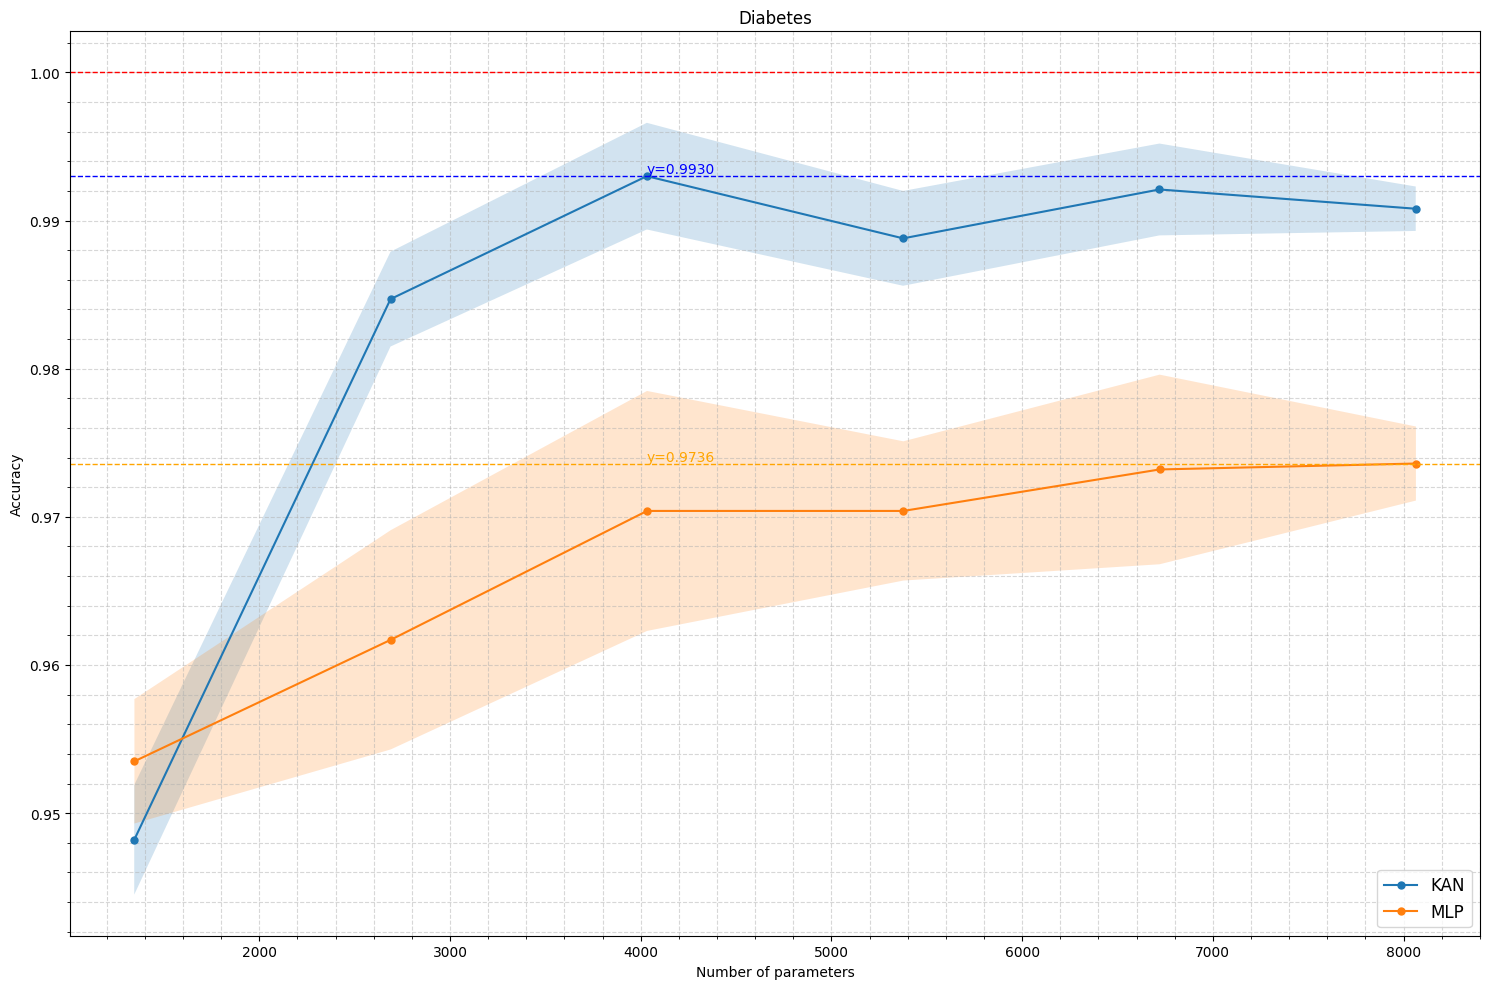

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

df =  [
{
    'dataset':  "Diabetes",
    'n_params':  [[],
                  []],
    'accuracy_mean': [[],
                      []],
    'accuracy_std':  [[],
                      []],
    'model':     ["KAN","MLP"]
}
]

kan_files = sorted(glob.glob("KAN*"), key=lambda file: int(file.strip("KAN_.txt")))

for file in kan_files:
    with open(file, "r") as f:
        content = f.read()
        df[0]["n_params"][0].append(int(file.strip("KAN_.txt")))
        df[0]["accuracy_mean"][0].append(float(content.split()[0]))
        df[0]["accuracy_std"][0].append(float(content.split()[1]))

df[0]["n_params"][0] = np.array(df[0]["n_params"][0])
df[0]["accuracy_mean"][0] = np.array(df[0]["accuracy_mean"][0])
df[0]["accuracy_std"][0] = np.array(df[0]["accuracy_std"][0])

mlp_files = sorted(glob.glob("MLP*"), key=lambda file: int(file.strip("MLP_.txt")))

for file in mlp_files:
    with open(file, "r") as f:
        content = f.read()
        df[0]["n_params"][1].append(int(file.strip("MLP_.txt")))
        df[0]["accuracy_mean"][1].append(float(content.split()[0]))
        df[0]["accuracy_std"][1].append(float(content.split()[1]))

df[0]["n_params"][1] = np.array(df[0]["n_params"][1])
df[0]["accuracy_mean"][1] = np.array(df[0]["accuracy_mean"][1])
df[0]["accuracy_std"][1] = np.array(df[0]["accuracy_std"][1])



fig, axes = plt.subplots(1, 1, figsize=(15, 10), sharex=False, sharey=False)

for i in range(len(df)):
    for j in range(len(df[i]['model'])):
        axes.plot(df[i]['n_params'][j], df[i]['accuracy_mean'][j],
            label=df[i]['model'][j], linestyle='-', marker='o', markersize=5)
        axes.fill_between(df[i]['n_params'][j],
                        df[i]['accuracy_mean'][j] - df[i]['accuracy_std'][j],
                        df[i]['accuracy_mean'][j] + df[i]['accuracy_std'][j],
                        alpha=0.2)
    axes.set_title(df[i]['dataset'])
    axes.set_xlabel('Number of parameters')
    axes.set_ylabel('Accuracy')

    axes.axhline(y=1, color='red', linestyle='--', linewidth=1)

    axes.axhline(y=max(df[0]["accuracy_mean"][0]), color='blue', linestyle='--', linewidth=1)
    axes.text(x=0.5 * max(df[0]["n_params"][0]), y=max(df[0]["accuracy_mean"][0]), 
          s=f'y={max(df[0]["accuracy_mean"][0]):.4f}', color='blue', fontsize=10, va='bottom')

    axes.axhline(y=max(df[0]["accuracy_mean"][1]), color='orange', linestyle='--', linewidth=1)
    axes.text(x=0.5 * max(df[0]["n_params"][1]), y=max(df[0]["accuracy_mean"][1]), 
          s=f'y={max(df[0]["accuracy_mean"][1]):.4f}', color='orange', fontsize=10, va='bottom')
    
    axes.grid(which='both', linestyle='--', alpha=0.5)
    axes.minorticks_on()

axes.legend(loc='best', fontsize=12)

plt.tight_layout()
plt.show()
